<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 144 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Survival Analysis &middot; Challenge Solutions</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Worked solutions: naive vs survival, the Kaplan-Meier curve, comparing contracts with log-rank, Cox hazard ratios, and checking proportional hazards.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.duration.hazard_regression import PHReg
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, GR, BL = "#a21caf", "#16a34a", "#2563eb"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "survival-analysis--subscription-churn.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

def St(sf, t):                       # survival probability at time t from a fitted KM curve
    i = np.searchsorted(sf.surv_times, t, side="right") - 1
    return 1.0 if i < 0 else float(sf.surv_prob[i])
def median_surv(sf):                 # smallest time where S(t) <= 0.5 (nan if never reached)
    below = sf.surv_times[sf.surv_prob <= 0.5]
    return float(below[0]) if len(below) else np.nan

(1000, 5)
  customer_id        contract  monthly_charges  tenure_months  churned
0     S300000          annual            63.80          24.00        0
1     S300001          annual            56.36          24.00        0
2     S300002          annual            87.30          24.00        0
3     S300003  month-to-month            86.68          12.97        1
4     S300004          annual            77.71           2.77        1


## Challenge 1 &middot; Naive vs survival
Both naive averages are biased downward because they mishandle the censored (still-active) customers. The KM median uses them correctly.

In [2]:
sf = SurvfuncRight(df.tenure_months, df.churned)
print(f"mean tenure of churners only : {df.loc[df.churned==1,'tenure_months'].mean():.1f} months")
print(f"mean tenure of everyone      : {df.tenure_months.mean():.1f} months")
print(f"Kaplan-Meier median survival : {median_surv(sf):.1f} months (the honest summary)")

mean tenure of churners only : 9.6 months
mean tenure of everyone      : 14.9 months
Kaplan-Meier median survival : 20.9 months (the honest summary)


## Challenge 2 &middot; Kaplan-Meier curve
Plot S(t) and read survival at 6, 12, and 24 months.

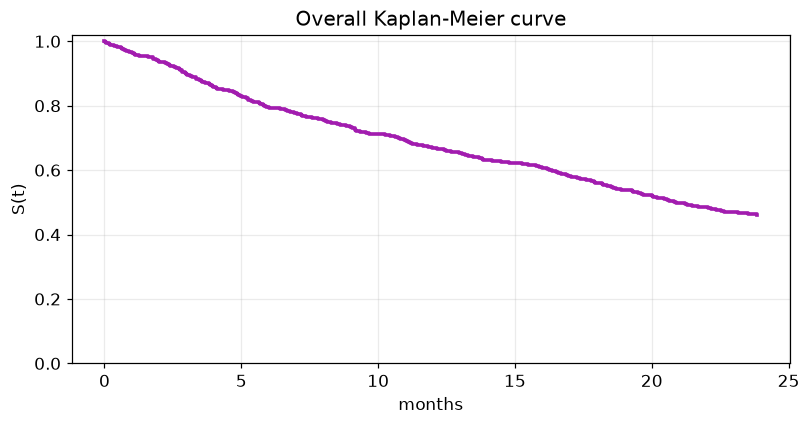

S(6) = 0.80
S(12) = 0.67
S(24) = 0.46


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.step(np.r_[0, sf.surv_times], np.r_[1, sf.surv_prob], where="post", color=FU, lw=2.4)
ax.set_xlabel("months"); ax.set_ylabel("S(t)"); ax.set_title("Overall Kaplan-Meier curve"); ax.set_ylim(0,1.02)
plt.tight_layout(); plt.show()
for t in [6,12,24]: print(f"S({t}) = {St(sf,t):.2f}")

## Challenge 3 &middot; Compare contracts
Overlay the two curves and run the log-rank test.

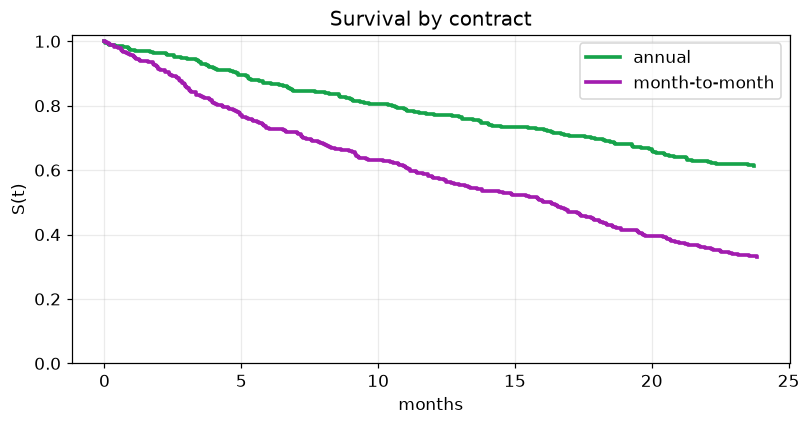

log-rank chi-square = 72.6, p = 0.00e+00


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for g, col in [("annual", GR), ("month-to-month", FU)]:
    sub = df[df.contract==g]; sfg = SurvfuncRight(sub.tenure_months, sub.churned)
    ax.step(np.r_[0, sfg.surv_times], np.r_[1, sfg.surv_prob], where="post", color=col, lw=2.4, label=g)
ax.set_ylim(0,1.02); ax.set_xlabel("months"); ax.set_ylabel("S(t)"); ax.legend(); ax.set_title("Survival by contract")
plt.tight_layout(); plt.show()
chisq, p = survdiff(df.tenure_months, df.churned, df.contract)
print(f"log-rank chi-square = {chisq:.1f}, p = {p:.2e}")

## Challenge 4 &middot; Cox hazard ratios
Interpret each HR in plain language.

In [5]:
d = df.copy()
d["m2m"] = (d.contract=="month-to-month").astype(float)
d["charges_std"] = (d.monthly_charges - d.monthly_charges.mean())/d.monthly_charges.std()
cox = PHReg.from_formula("tenure_months ~ m2m + charges_std", data=d, status=d.churned).fit()
hr = np.exp(np.asarray(cox.params))
for nm, h in zip(cox.model.exog_names, hr):
    print(f"{nm:12s}: HR = {h:.2f}")
print("\nMonth-to-month customers have ~2.24x the instantaneous churn risk of annual;")
print("each SD (~$22) higher monthly charge multiplies the hazard by ~1.48.")

m2m         : HR = 2.24
charges_std : HR = 1.48

Month-to-month customers have ~2.24x the instantaneous churn risk of annual;
each SD (~$22) higher monthly charge multiplies the hazard by ~1.48.


## Challenge 5 &middot; Check proportional hazards
The Cox model assumes the hazard ratio is constant over time. You check it and react if it fails.

How to check proportional hazards for `contract`:
1. Plot log(-log(S(t))) for each group; roughly parallel curves support PH.
2. Test scaled Schoenfeld residuals vs time (lifelines: check_assumptions;
   R survival: cox.zph). A significant slope flags a violation.
If PH fails: stratify by contract, add a time-varying (time x contract) term,
or switch to an accelerated failure time (AFT) model.


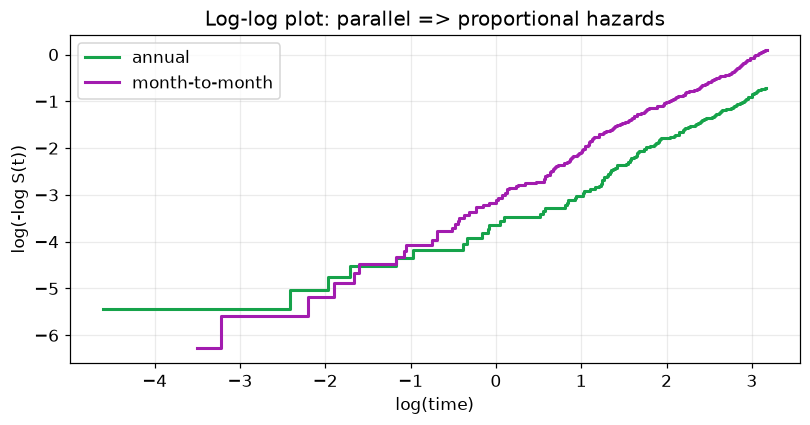

In [6]:
print("How to check proportional hazards for `contract`:")
print("1. Plot log(-log(S(t))) for each group; roughly parallel curves support PH.")
print("2. Test scaled Schoenfeld residuals vs time (lifelines: check_assumptions;")
print("   R survival: cox.zph). A significant slope flags a violation.")
print("If PH fails: stratify by contract, add a time-varying (time x contract) term,")
print("or switch to an accelerated failure time (AFT) model.")
# quick visual: log-log survival by group
fig, ax = plt.subplots(figsize=(7.5,4))
for g, col in [("annual", GR), ("month-to-month", FU)]:
    sub = df[df.contract==g]; sfg = SurvfuncRight(sub.tenure_months, sub.churned)
    m = sfg.surv_prob > 0
    ax.step(np.log(sfg.surv_times[m]), np.log(-np.log(sfg.surv_prob[m])), where="post", color=col, lw=2, label=g)
ax.set_xlabel("log(time)"); ax.set_ylabel("log(-log S(t))"); ax.set_title("Log-log plot: parallel => proportional hazards"); ax.legend()
plt.tight_layout(); plt.show()